In [5]:
# ════════════════════════════════════════════════════════════
# CELL 1 — Import library
# ════════════════════════════════════════════════════════════
 
import os
import time
import numpy as np
import matplotlib.pyplot as plt
 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.models as models
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler
 
from sklearn.metrics import (
    f1_score,
    precision_score,
    recall_score,
    average_precision_score,
    roc_auc_score,
    hamming_loss,
)
 
import warnings
warnings.filterwarnings("ignore")
 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device      : {device}")
if torch.cuda.is_available():
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    total_vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"VRAM        : {total_vram:.1f} GB")
print(f"PyTorch     : {torch.__version__}")
print(f"Torchvision : {torchvision.__version__}")
print("\nSemua library berhasil diimport ✓")

Device      : cuda
GPU         : Tesla T4
VRAM        : 15.6 GB
PyTorch     : 2.10.0+cu128
Torchvision : 0.25.0+cu128

Semua library berhasil diimport ✓


In [6]:
# ════════════════════════════════════════════════════════════
# CELL 2 — Verifikasi path dataset
# ════════════════════════════════════════════════════════════
 
PREPROCESSED_PATH = (
    "/kaggle/input/datasets/shafiyahnurilhayya/"
    "movie-genre-preprocessed/preprocessed_data.pt"
)
 
print("Verifikasi path dataset:")
print(f"  Path : {PREPROCESSED_PATH}")
print(f"  Ada  : {os.path.exists(PREPROCESSED_PATH)}")
 
if not os.path.exists(PREPROCESSED_PATH):
    print("\n⚠️  File tidak ditemukan! Isi /kaggle/input:")
    for folder in os.listdir('/kaggle/input'):
        print(f"  {folder}/")
        try:
            for sub in os.listdir(f'/kaggle/input/{folder}'):
                print(f"    └─ {sub}")
        except Exception:
            pass
    raise FileNotFoundError(
        "Sesuaikan PREPROCESSED_PATH dengan path yang muncul di atas."
    )
 
print("✓ Path valid. Lanjut ke Cell 3.")

Verifikasi path dataset:
  Path : /kaggle/input/datasets/shafiyahnurilhayya/movie-genre-preprocessed/preprocessed_data.pt
  Ada  : True
✓ Path valid. Lanjut ke Cell 3.


In [7]:
# ════════════════════════════════════════════════════════════
# CELL 3 — Load data hasil preprocessing
# ════════════════════════════════════════════════════════════
 
print("Memuat data dari file preprocessing...")
data = torch.load(PREPROCESSED_PATH, map_location='cpu')
 
X_train        = data["X_train"]
y_train        = data["y_train"]
X_val          = data["X_val"]
y_val          = data["y_val"]
X_test         = data["X_test"]
y_test         = data["y_test"]
GENRE_COLS     = data["genre_cols"]
pos_weight     = data["pos_weight"]
sample_weights = data["sample_weights"]
 
N_GENRES = len(GENRE_COLS)
 
print(f"\nData berhasil dimuat:")
print(f"  X_train : {tuple(X_train.shape)}  dtype: {X_train.dtype}")
print(f"  y_train : {tuple(y_train.shape)}  dtype: {y_train.dtype}")
print(f"  X_val   : {tuple(X_val.shape)}")
print(f"  y_val   : {tuple(y_val.shape)}")
print(f"  X_test  : {tuple(X_test.shape)}")
print(f"  y_test  : {tuple(y_test.shape)}")
 
n_total = X_train.shape[0] + X_val.shape[0] + X_test.shape[0]
print(f"\n  Total   : {n_total} gambar (harus = 300)")
print(f"  Genre   : {GENRE_COLS}")
print(f"\nVerifikasi normalisasi:")
print(f"  X_train min/max : {X_train.min():.3f} / {X_train.max():.3f}")
print(f"  (nilai di luar [0,1] normal setelah normalisasi ImageNet)")

Memuat data dari file preprocessing...

Data berhasil dimuat:
  X_train : (192, 3, 224, 224)  dtype: torch.float32
  y_train : (192, 14)  dtype: torch.float32
  X_val   : (50, 3, 224, 224)
  y_val   : (50, 14)
  X_test  : (50, 3, 224, 224)
  y_test  : (50, 14)

  Total   : 292 gambar (harus = 300)
  Genre   : ['action', 'adventure', 'animation', 'comedy', 'crime', 'drama', 'family', 'fantasy', 'horror', 'musical', 'mystery', 'romance', 'scifi', 'thriller']

Verifikasi normalisasi:
  X_train min/max : -2.118 / 2.640
  (nilai di luar [0,1] normal setelah normalisasi ImageNet)


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 4 — Buat DataLoader
# ════════════════════════════════════════════════════════════
 
BATCH_SIZE  = 32
NUM_WORKERS = 0
 
n_train = X_train.shape[0]
 
if len(sample_weights) != n_train:
    print(f"⚠️  Menyesuaikan sample_weights: "
          f"{len(sample_weights)} → {n_train}")
    if len(sample_weights) > n_train:
        sample_weights_fixed = sample_weights[:n_train]
    else:
        repeat_times = (n_train // len(sample_weights)) + 1
        sample_weights_fixed = sample_weights.repeat(repeat_times)[:n_train]
else:
    sample_weights_fixed = sample_weights
    print(f"✓ sample_weights sesuai: {len(sample_weights_fixed)}")
 
sampler = WeightedRandomSampler(
    weights     = sample_weights_fixed,
    num_samples = n_train,
    replacement = True,
)
 
train_ds = TensorDataset(X_train, y_train)
val_ds   = TensorDataset(X_val,   y_val)
test_ds  = TensorDataset(X_test,  y_test)
 
train_loader = DataLoader(
    train_ds,
    batch_size  = BATCH_SIZE,
    sampler     = sampler,
    num_workers = NUM_WORKERS,
    pin_memory  = torch.cuda.is_available(),
    drop_last   = False,
)
val_loader = DataLoader(
    val_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = torch.cuda.is_available(),
)
test_loader = DataLoader(
    test_ds,
    batch_size  = BATCH_SIZE,
    shuffle     = False,
    num_workers = NUM_WORKERS,
    pin_memory  = torch.cuda.is_available(),
)
 
imgs, labels = next(iter(train_loader))
print(f"\nDataLoader berhasil dibuat:")
print(f"  train_loader : {len(train_loader)} batch/epoch")
print(f"  val_loader   : {len(val_loader)} batch")
print(f"  test_loader  : {len(test_loader)} batch")
print(f"\nVerifikasi batch pertama:")
print(f"  imgs.shape   : {tuple(imgs.shape)}")
print(f"  labels.shape : {tuple(labels.shape)}")
print(f"  imgs range   : [{imgs.min():.3f}, {imgs.max():.3f}]")
print(f"  labels dtype : {labels.dtype}")
print("\n✓ DataLoader siap.")

⚠️  Menyesuaikan sample_weights: 200 → 192

DataLoader berhasil dibuat:
  train_loader : 6 batch/epoch
  val_loader   : 2 batch
  test_loader  : 2 batch

Verifikasi batch pertama:
  imgs.shape   : (32, 3, 224, 224)
  labels.shape : (32, 14)
  imgs range   : [-2.118, 2.640]
  labels dtype : torch.float32

✓ DataLoader siap.


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 5 — Definisi model DenseNet121
# ════════════════════════════════════════════════════════════
 
MODEL_NAME = "DenseNet121"
 
def build_densenet121(
    n_classes      : int   = 14,
    dropout        : float = 0.2,
    freeze_backbone: bool  = True,
) -> nn.Module:
    """
    DenseNet121 pretrained ImageNet untuk multilabel classification.
 
    Perubahan dari versi sebelumnya:
    - dropout 0.3 → 0.2: lebih sedikit regularisasi agar model
      bisa belajar lebih optimal dari dataset kecil
    """
    model = models.densenet121(weights="IMAGENET1K_V1")
 
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
 
    in_features = model.classifier.in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=dropout),
        nn.Linear(in_features, n_classes),
    )
 
    return model.to(device)
 
 
model = build_densenet121(freeze_backbone=True)
 
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters()
                       if p.requires_grad)
frozen_params    = total_params - trainable_params
 
print(f"Model         : {MODEL_NAME}")
print(f"Total param   : {total_params:>12,}")
print(f"Trainable     : {trainable_params:>12,}  ← dilatih Phase 1")
print(f"Frozen        : {frozen_params:>12,}  ← pretrained, dibekukan")
print(f"\nClassifier head baru (dropout=0.2):")
print(model.classifier)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 244MB/s]


Model         : DenseNet121
Total param   :    6,968,206
Trainable     :       14,350  ← dilatih Phase 1
Frozen        :    6,953,856  ← pretrained, dibekukan

Classifier head baru (dropout=0.2):
Sequential(
  (0): Dropout(p=0.2, inplace=False)
  (1): Linear(in_features=1024, out_features=14, bias=True)
)


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 6 — Fungsi evaluasi (threshold = 0.5)
# ════════════════════════════════════════════════════════════
 
THRESHOLD = 0.5
 
def evaluate(model, loader, criterion):
    """
    Evaluasi model dengan threshold seragam 0.5.
    Mengembalikan semua metrik yang dibutuhkan untuk laporan.
    """
    model.eval()
    total_loss = 0.0
    all_probs, all_preds, all_labels = [], [], []
 
    with torch.no_grad():
        for imgs, labels in loader:
            imgs   = imgs.to(device)
            labels = labels.to(device)
 
            outputs    = model(imgs)
            loss       = criterion(outputs, labels)
            total_loss += loss.item()
 
            probs = torch.sigmoid(outputs)
            preds = (probs > THRESHOLD).float()
 
            all_probs.append(probs.cpu().numpy())
            all_preds.append(preds.cpu().numpy())
            all_labels.append(labels.cpu().numpy())
 
    all_probs  = np.concatenate(all_probs,  axis=0)
    all_preds  = np.concatenate(all_preds,  axis=0)
    all_labels = np.concatenate(all_labels, axis=0)
 
    exact_match = np.all(all_preds == all_labels, axis=1).mean()
 
    return {
        "loss"               : total_loss / len(loader),
        "f1_micro"           : f1_score(all_labels, all_preds,
                                         average='micro',    zero_division=0),
        "f1_macro"           : f1_score(all_labels, all_preds,
                                         average='macro',    zero_division=0),
        "f1_weighted"        : f1_score(all_labels, all_preds,
                                         average='weighted', zero_division=0),
        "f1_per_genre"       : f1_score(all_labels, all_preds,
                                         average=None,       zero_division=0),
        "precision_micro"    : precision_score(all_labels, all_preds,
                                                average='micro',    zero_division=0),
        "precision_macro"    : precision_score(all_labels, all_preds,
                                                average='macro',    zero_division=0),
        "precision_weighted" : precision_score(all_labels, all_preds,
                                                average='weighted', zero_division=0),
        "precision_per_genre": precision_score(all_labels, all_preds,
                                                average=None,       zero_division=0),
        "recall_micro"       : recall_score(all_labels, all_preds,
                                             average='micro',    zero_division=0),
        "recall_macro"       : recall_score(all_labels, all_preds,
                                             average='macro',    zero_division=0),
        "recall_weighted"    : recall_score(all_labels, all_preds,
                                             average='weighted', zero_division=0),
        "recall_per_genre"   : recall_score(all_labels, all_preds,
                                             average=None,       zero_division=0),
        "mAP"                : average_precision_score(all_labels, all_probs,
                                                        average='macro'),
        "auc_roc"            : roc_auc_score(all_labels, all_probs,
                                              average='weighted',
                                              multi_class='ovr'),
        "hamming_loss"       : hamming_loss(all_labels, all_preds),
        "exact_match"        : exact_match,
        "_probs"             : all_probs,
        "_preds"             : all_preds,
        "_labels"            : all_labels,
    }
 
 
print(f"Fungsi evaluate() siap ✓")
print(f"Threshold yang digunakan: {THRESHOLD} (seragam untuk semua genre)")

Fungsi evaluate() siap ✓
Threshold yang digunakan: 0.5 (seragam untuk semua genre)


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 6B — Focal Loss
# ════════════════════════════════════════════════════════════
 
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, pos_weight=None):
        """
        gamma     : focusing parameter (0 = BCE biasa, 2 = recommended)
        pos_weight: sama dengan pos_weight di BCEWithLogitsLoss
        """
        super().__init__()
        self.gamma      = gamma
        self.pos_weight = pos_weight
 
    def forward(self, inputs, targets):
        bce = F.binary_cross_entropy_with_logits(
            inputs, targets,
            pos_weight = self.pos_weight,
            reduction  = 'none'
        )
        probs = torch.sigmoid(inputs)
        p_t = probs * targets + (1 - probs) * (1 - targets)
        focal_weight = (1 - p_t) ** self.gamma
        return (focal_weight * bce).mean()
 
 
print("FocalLoss class siap ✓")
print("gamma=2.0 → fokus pada genre yang masih sering salah diprediksi")

FocalLoss class siap ✓
gamma=2.0 → fokus pada genre yang masih sering salah diprediksi


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 7 — Setup loss, optimizer, scheduler
# ════════════════════════════════════════════════════════════

boost_config = {
    'romance': 3.0,
    'musical': 3.0,
    'horror' : 2.0,
    'family' : 1.5,
}
 
pos_weight_boosted = pos_weight.clone()
print("pos_weight setelah boost:")
for i, g in enumerate(GENRE_COLS):
    original = pos_weight[i].item()
    if g in boost_config:
        pos_weight_boosted[i] = pos_weight[i] * boost_config[g]
        boosted = pos_weight_boosted[i].item()
        print(f"  {g:<12}: {original:.2f} → {boosted:.2f}  "
              f"(×{boost_config[g]})")
    else:
        print(f"  {g:<12}: {original:.2f}  (tidak diubah)")
 
criterion = FocalLoss(
    gamma      = 2.0,
    pos_weight = pos_weight_boosted.to(device),
)
 
optimizer_p1 = torch.optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr           = 1e-3,
    weight_decay = 1e-4,
)
scheduler_p1 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=15
)
 
print(f"\nSetup Phase 1:")
print(f"  Loss      : FocalLoss(gamma=2.0) + pos_weight boosted")
print(f"  Optimizer : Adam lr=1e-3, weight_decay=1e-4")
print(f"  Scheduler : CosineAnnealingLR T_max=15")

pos_weight setelah boost:
  action      : 0.52  (tidak diubah)
  adventure   : 1.00  (tidak diubah)
  animation   : 4.41  (tidak diubah)
  comedy      : 2.12  (tidak diubah)
  crime       : 4.26  (tidak diubah)
  drama       : 0.71  (tidak diubah)
  family      : 6.14 → 9.21  (×1.5)
  fantasy     : 2.57  (tidak diubah)
  horror      : 9.53 → 19.05  (×2.0)
  musical     : 49.00 → 147.00  (×3.0)
  mystery     : 5.06  (tidak diubah)
  romance     : 5.90 → 17.69  (×3.0)
  scifi       : 2.45  (tidak diubah)
  thriller    : 2.51  (tidak diubah)

Setup Phase 1:
  Loss      : FocalLoss(gamma=2.0) + pos_weight boosted
  Optimizer : Adam lr=1e-3, weight_decay=1e-4
  Scheduler : CosineAnnealingLR T_max=15


In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 8 — Phase 1: Training classifier head (10 epoch)
# ════════════════════════════════════════════════════════════
 
PHASE1_EPOCHS = 10
 
history = {
    'train_loss'  : [],
    'val_loss'    : [],
    'val_f1_micro': [],
    'val_f1_macro': [],
    'val_mAP'     : [],
}
epoch_times  = []
best_val_f1_macro = 0.0
best_weights = None
best_epoch   = 0
 
print("=" * 65)
print(f"  PHASE 1 — Training Classifier Head ({PHASE1_EPOCHS} epoch)")
print(f"  Backbone : FROZEN  |  Hanya classifier head yang dilatih")
print(f"  Loss     : FocalLoss(gamma=2.0)")
print("=" * 65)
 
for epoch in range(PHASE1_EPOCHS):
    epoch_start = time.time()
 
    model.train()
    train_loss = 0.0
 
    for imgs, labels in train_loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)
 
        optimizer_p1.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer_p1.step()
        train_loss += loss.item()
 
    scheduler_p1.step()
    avg_train = train_loss / len(train_loader)
 
    val_m   = evaluate(model, val_loader, criterion)
    elapsed = time.time() - epoch_start
    epoch_times.append(elapsed)
 
    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_m['loss'])
    history['val_f1_micro'].append(val_m['f1_micro'])
    history['val_f1_macro'].append(val_m['f1_macro'])
    history['val_mAP'].append(val_m['mAP'])
 
    if val_m['f1_macro'] > best_val_f1_macro:
        best_val_f1_macro = val_m['f1_macro']
        best_epoch        = epoch + 1
        best_weights      = {k: v.clone() for k, v in model.state_dict().items()}
        marker = "  ★ best"
    else:
        marker = ""
 
    print(f"Epoch [{epoch+1:2d}/{PHASE1_EPOCHS}] "
          f"{elapsed:4.0f}s | "
          f"train={avg_train:.4f} | "
          f"val={val_m['loss']:.4f} | "
          f"F1mi={val_m['f1_micro']:.4f} | "
          f"F1ma={val_m['f1_macro']:.4f} | "
          f"mAP={val_m['mAP']:.4f}"
          f"{marker}")
 
print(f"\nPhase 1 selesai. Best val F1-macro: {best_val_f1_macro:.4f} "
      f"(epoch {best_epoch})")

  PHASE 1 — Training Classifier Head (10 epoch)
  Backbone : FROZEN  |  Hanya classifier head yang dilatih
  Loss     : FocalLoss(gamma=2.0)
Epoch [ 1/10]    2s | train=0.4361 | val=0.4061 | F1mi=0.3526 | F1ma=0.3298 | mAP=0.3895  ★ best
Epoch [ 2/10]    1s | train=0.3542 | val=0.3352 | F1mi=0.3302 | F1ma=0.3307 | mAP=0.4155  ★ best
Epoch [ 3/10]    1s | train=0.2872 | val=0.2847 | F1mi=0.4342 | F1ma=0.3810 | mAP=0.4238  ★ best
Epoch [ 4/10]    1s | train=0.2530 | val=0.2775 | F1mi=0.4596 | F1ma=0.4176 | mAP=0.4541  ★ best
Epoch [ 5/10]    1s | train=0.2464 | val=0.2814 | F1mi=0.3955 | F1ma=0.3757 | mAP=0.4655
Epoch [ 6/10]    1s | train=0.2187 | val=0.2804 | F1mi=0.4547 | F1ma=0.4180 | mAP=0.4706  ★ best
Epoch [ 7/10]    1s | train=0.2104 | val=0.2867 | F1mi=0.4475 | F1ma=0.4092 | mAP=0.4938
Epoch [ 8/10]    1s | train=0.1871 | val=0.2856 | F1mi=0.4138 | F1ma=0.3630 | mAP=0.4981
Epoch [ 9/10]    1s | train=0.1829 | val=0.2820 | F1mi=0.4787 | F1ma=0.4224 | mAP=0.4932  ★ best
Epoch [10/

In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 9 — Phase 2: Fine-tune seluruh model (40 epoch)
# ════════════════════════════════════════════════════════════
 
PHASE2_EPOCHS = 40
 
for param in model.parameters():
    param.requires_grad = True
 
total_trainable = sum(p.numel() for p in model.parameters()
                      if p.requires_grad)
 
optimizer_p2 = torch.optim.Adam(
    model.parameters(),
    lr           = 1e-5,
    weight_decay = 1e-4,
)
scheduler_p2 = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=PHASE2_EPOCHS
)
 
print("=" * 65)
print(f"  PHASE 2 — Fine-tuning Seluruh Model ({PHASE2_EPOCHS} epoch)")
print(f"  Backbone : UNFROZEN  |  {total_trainable:,} parameter dilatih")
print(f"  lr       : 1e-5 | Loss: FocalLoss(gamma=2.0)")
print("=" * 65)
 
for epoch in range(PHASE2_EPOCHS):
    epoch_start = time.time()
 
    model.train()
    train_loss = 0.0
 
    for imgs, labels in train_loader:
        imgs   = imgs.to(device)
        labels = labels.to(device)
 
        optimizer_p2.zero_grad()
        outputs = model(imgs)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer_p2.step()
        train_loss += loss.item()
 
    scheduler_p2.step()
    avg_train = train_loss / len(train_loader)
 
    val_m   = evaluate(model, val_loader, criterion)
    elapsed = time.time() - epoch_start
    epoch_times.append(elapsed)
 
    history['train_loss'].append(avg_train)
    history['val_loss'].append(val_m['loss'])
    history['val_f1_micro'].append(val_m['f1_micro'])
    history['val_f1_macro'].append(val_m['f1_macro'])
    history['val_mAP'].append(val_m['mAP'])
 
    if val_m['f1_macro'] > best_val_f1_macro:
        best_val_f1_macro = val_m['f1_macro']
        best_epoch        = PHASE1_EPOCHS + epoch + 1
        best_weights      = {k: v.clone() for k, v in model.state_dict().items()}
        marker = "  ★ best"
    else:
        marker = ""
 
    print(f"Epoch [{epoch+1:2d}/{PHASE2_EPOCHS}] "
          f"{elapsed:4.0f}s | "
          f"train={avg_train:.4f} | "
          f"val={val_m['loss']:.4f} | "
          f"F1mi={val_m['f1_micro']:.4f} | "
          f"F1ma={val_m['f1_macro']:.4f} | "
          f"mAP={val_m['mAP']:.4f}"
          f"{marker}")
 
TOTAL_EPOCHS   = PHASE1_EPOCHS + PHASE2_EPOCHS
avg_epoch_time = np.mean(epoch_times)
 
print(f"\nPhase 2 selesai.")
print(f"Best val F1-macro : {best_val_f1_macro:.4f} (epoch {best_epoch})")
print(f"Rata-rata waktu/epoch : {avg_epoch_time:.1f} detik")

  PHASE 2 — Fine-tuning Seluruh Model (40 epoch)
  Backbone : UNFROZEN  |  6,968,206 parameter dilatih
  lr       : 1e-5 | Loss: FocalLoss(gamma=2.0)
Epoch [ 1/40]    2s | train=0.1913 | val=0.2779 | F1mi=0.4921 | F1ma=0.4441 | mAP=0.5059  ★ best
Epoch [ 2/40]    2s | train=0.1659 | val=0.2766 | F1mi=0.4911 | F1ma=0.4427 | mAP=0.5093
Epoch [ 3/40]    2s | train=0.1500 | val=0.2729 | F1mi=0.4854 | F1ma=0.4364 | mAP=0.5157
Epoch [ 4/40]    2s | train=0.1498 | val=0.2717 | F1mi=0.4784 | F1ma=0.4315 | mAP=0.5169
Epoch [ 5/40]    2s | train=0.1344 | val=0.2724 | F1mi=0.4832 | F1ma=0.4357 | mAP=0.5192
Epoch [ 6/40]    2s | train=0.1356 | val=0.2711 | F1mi=0.4790 | F1ma=0.4259 | mAP=0.5202
Epoch [ 7/40]    2s | train=0.1312 | val=0.2723 | F1mi=0.4789 | F1ma=0.4276 | mAP=0.5223
Epoch [ 8/40]    2s | train=0.1216 | val=0.2708 | F1mi=0.4858 | F1ma=0.4402 | mAP=0.5268
Epoch [ 9/40]    2s | train=0.1236 | val=0.2709 | F1mi=0.4776 | F1ma=0.4354 | mAP=0.5308
Epoch [10/40]    2s | train=0.1202 | val=

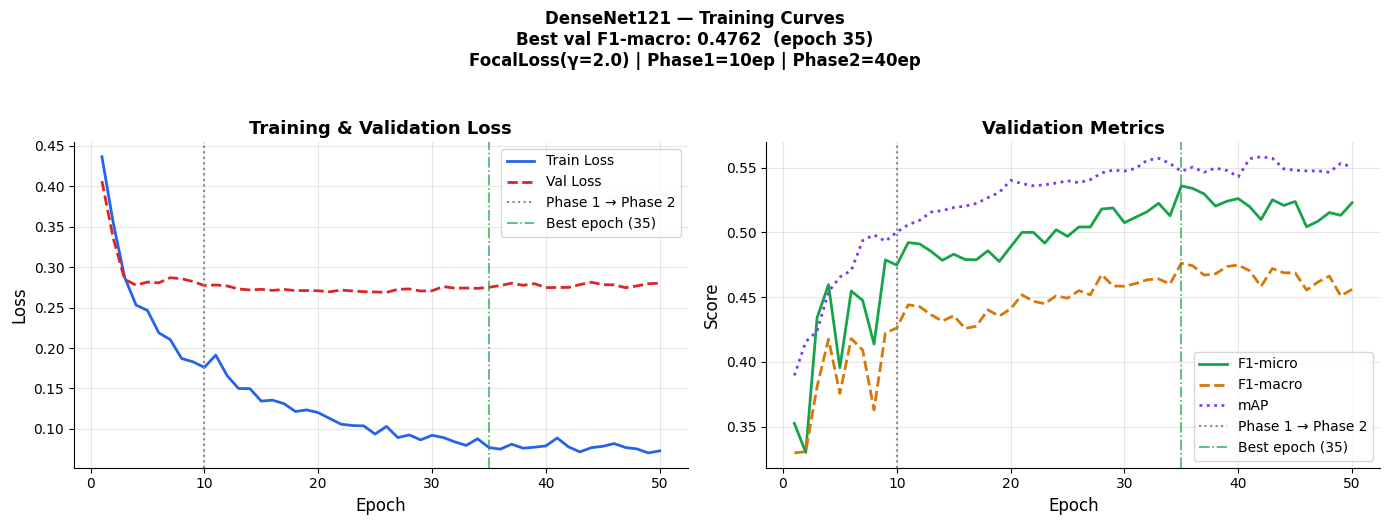

Plot disimpan: /kaggle/working/DenseNet121_training_curves.png


In [16]:
# ════════════════════════════════════════════════════════════
# CELL 10 — Plot kurva training
# ════════════════════════════════════════════════════════════
 
ep = range(1, TOTAL_EPOCHS + 1)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
 
axes[0].plot(ep, history['train_loss'],
             label='Train Loss', color='#2563EB', linewidth=2)
axes[0].plot(ep, history['val_loss'],
             label='Val Loss',   color='#DC2626', linewidth=2, linestyle='--')
axes[0].axvline(x=PHASE1_EPOCHS, color='#888780',
                linestyle=':', linewidth=1.5, label='Phase 1 → Phase 2')
axes[0].axvline(x=best_epoch, color='#16A34A',
                linestyle='-.', linewidth=1.2, alpha=0.8,
                label=f'Best epoch ({best_epoch})')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss',  fontsize=12)
axes[0].set_title('Training & Validation Loss',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)
axes[0].spines[['top', 'right']].set_visible(False)
 
axes[1].plot(ep, history['val_f1_micro'],
             label='F1-micro', color='#16A34A', linewidth=2)
axes[1].plot(ep, history['val_f1_macro'],
             label='F1-macro', color='#D97706', linewidth=2, linestyle='--')
axes[1].plot(ep, history['val_mAP'],
             label='mAP',      color='#7C3AED', linewidth=2, linestyle=':')
axes[1].axvline(x=PHASE1_EPOCHS, color='#888780',
                linestyle=':', linewidth=1.5, label='Phase 1 → Phase 2')
axes[1].axvline(x=best_epoch, color='#16A34A',
                linestyle='-.', linewidth=1.2, alpha=0.8,
                label=f'Best epoch ({best_epoch})')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Score', fontsize=12)
axes[1].set_title('Validation Metrics', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(alpha=0.3)
axes[1].spines[['top', 'right']].set_visible(False)
 
plt.suptitle(
    f'{MODEL_NAME} — Training Curves\n'
    f'Best val F1-macro: {best_val_f1_macro:.4f}  (epoch {best_epoch})\n'
    f'FocalLoss(γ=2.0) | Phase1={PHASE1_EPOCHS}ep | Phase2={PHASE2_EPOCHS}ep',
    fontsize=12, fontweight='bold', y=1.04
)
plt.tight_layout()
plot_path = f'/kaggle/working/{MODEL_NAME}_training_curves.png'
plt.savefig(plot_path, dpi=180, bbox_inches='tight')
plt.show()
print(f"Plot disimpan: {plot_path}")

In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 11 — Evaluasi final + matriks performa lengkap
# ════════════════════════════════════════════════════════════
 
model.load_state_dict(best_weights)
print(f"Model terbaik (epoch {best_epoch}) dimuat kembali.\n")
 
# Hitung inference time
model.eval()
dummy = X_test[:1].to(device)
 
with torch.no_grad():
    for _ in range(10):
        _ = model(dummy)
 
infer_times = []
with torch.no_grad():
    for _ in range(100):
        t0 = time.time()
        _  = model(dummy)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        infer_times.append((time.time() - t0) * 1000)
 
avg_infer_ms = np.mean(infer_times)
std_infer_ms = np.std(infer_times)
 
# Evaluasi test set & val set
test_m      = evaluate(model, test_loader, criterion)
val_m_final = evaluate(model, val_loader,  criterion)
 
# TABEL 1: Per genre
print("=" * 75)
print(f"  TABEL 1 — MATRIKS PERFORMA PER GENRE — {MODEL_NAME} (TEST SET)")
print(f"  Threshold: {THRESHOLD} (seragam semua model)")
print("=" * 75)
print(f"  {'Genre':<12} {'Precision':>10} {'Recall':>8} "
      f"{'F1-score':>10} {'Support':>9}")
print("  " + "─" * 55)
 
y_test_np = y_test.numpy().astype(int)
for i, g in enumerate(GENRE_COLS):
    support   = int(y_test_np[:, i].sum())
    precision = test_m['precision_per_genre'][i]
    recall    = test_m['recall_per_genre'][i]
    f1        = test_m['f1_per_genre'][i]
    flag      = "  ⚠ minoritas" if support <= 3 else ""
    print(f"  {g:<12} {precision:>10.4f} {recall:>8.4f} {f1:>10.4f} "
          f"{support:>9}{flag}")
 
print("  " + "─" * 55)
for avg_type in ['micro', 'macro', 'weighted']:
    prec  = test_m[f'precision_{avg_type}']
    rec   = test_m[f'recall_{avg_type}']
    f1    = test_m[f'f1_{avg_type}']
    supp  = int(y_test_np.sum()) if avg_type == 'micro' else ''
    label = f"{avg_type.capitalize()} avg"
    print(f"  {label:<12} {prec:>10.4f} {rec:>8.4f} {f1:>10.4f} "
          f"{str(supp):>9}")
 
# TABEL 2: Keseluruhan model
print(f"\n{'=' * 60}")
print(f"  TABEL 2 — MATRIKS PERFORMA KESELURUHAN — {MODEL_NAME}")
print(f"{'=' * 60}")
 
metrics_overall = [
    ("Validation Loss",           f"{val_m_final['loss']:.4f}"),
    ("─── Micro Average ───",     ""),
    ("  Precision (Micro)",        f"{test_m['precision_micro']:.4f}"),
    ("  Recall    (Micro)",        f"{test_m['recall_micro']:.4f}"),
    ("  F1-score  (Micro)",        f"{test_m['f1_micro']:.4f}"),
    ("─── Macro Average ───",     ""),
    ("  Precision (Macro)",        f"{test_m['precision_macro']:.4f}"),
    ("  Recall    (Macro)",        f"{test_m['recall_macro']:.4f}"),
    ("  F1-score  (Macro)",        f"{test_m['f1_macro']:.4f}"),
    ("─── Weighted Average ───",  ""),
    ("  Precision (Weighted)",     f"{test_m['precision_weighted']:.4f}"),
    ("  Recall    (Weighted)",     f"{test_m['recall_weighted']:.4f}"),
    ("  F1-score  (Weighted)",     f"{test_m['f1_weighted']:.4f}"),
    ("─── Metrik Tambahan ───",   ""),
    ("  Macro F1-score",           f"{test_m['f1_macro']:.4f}"),
    ("  Weighted F1-score",        f"{test_m['f1_weighted']:.4f}"),
    ("  Hamming Loss",             f"{test_m['hamming_loss']:.4f}"),
    ("  Exact Match Accuracy",     f"{test_m['exact_match']:.4f}"),
    ("  AUC-ROC (Weighted)",       f"{test_m['auc_roc']:.4f}"),
    ("  mAP (Macro)",              f"{test_m['mAP']:.4f}"),
    ("─── Efisiensi ───",         ""),
    ("  Jumlah Parameter",         f"{total_params:,}"),
    ("  Training Time/Epoch",      f"{avg_epoch_time:.1f} detik"),
    ("  Inference Time/Gambar",    f"{avg_infer_ms:.2f} ± {std_infer_ms:.2f} ms"),
    ("─── Konfigurasi ───",       ""),
    ("  Loss Function",            "FocalLoss(gamma=2.0)"),
    ("  Threshold",                f"{THRESHOLD}"),
    ("  Phase 1 Epochs",           f"{PHASE1_EPOCHS}"),
    ("  Phase 2 Epochs",           f"{PHASE2_EPOCHS}"),
    ("  Dropout",                  "0.2"),
]
 
for label, value in metrics_overall:
    if value == "":
        print(f"\n  {label}")
    else:
        print(f"  {label:<30}: {value}")
 
print(f"\n{'=' * 60}")

Model terbaik (epoch 35) dimuat kembali.

  TABEL 1 — MATRIKS PERFORMA PER GENRE — DenseNet121 (TEST SET)
  Threshold: 0.5 (seragam semua model)
  Genre         Precision   Recall   F1-score   Support
  ───────────────────────────────────────────────────────
  action           0.7353   0.6944     0.7143        36
  adventure        0.6000   0.6818     0.6383        22
  animation        0.6154   1.0000     0.7619         8
  comedy           0.4286   0.4615     0.4444        13
  crime            0.4231   0.8462     0.5641        13
  drama            0.7407   0.5882     0.6557        34
  family           0.2500   0.7500     0.3750         4
  fantasy          0.1538   0.1818     0.1667        11
  horror           0.1053   0.6667     0.1818         3  ⚠ minoritas
  musical          0.0000   0.0000     0.0000         0  ⚠ minoritas
  mystery          0.3000   0.4615     0.3636        13
  romance          0.0000   0.0000     0.0000         1  ⚠ minoritas
  scifi            0.3846   0.

INFERENSI — Contoh Prediksi pada Test Set
Threshold  : 0.5 (seragam, sama dengan model lain)
Seed       : 42 (seragam, sama dengan model lain)
N sampel   : 10
✓ sample_indices dibuat dan disimpan ke: /kaggle/working/sample_indices.npy
  Indeks   : [3, 4, 9, 19, 28, 32, 33, 39, 44, 49]

────────────────────────────────────────────────────────────


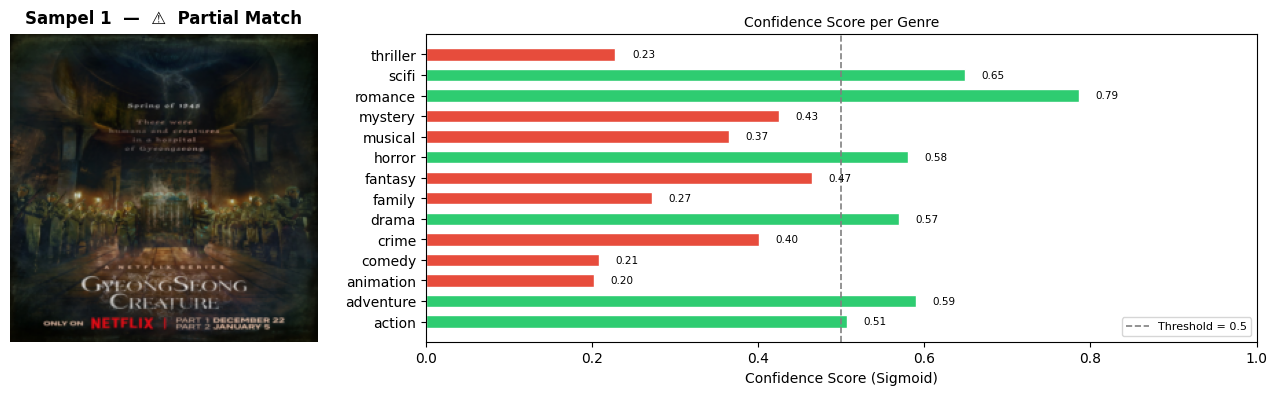


Sampel 1:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'drama', 'horror', 'mystery', 'thriller']
  Prediksi     : ['action', 'adventure', 'drama', 'horror', 'romance', 'scifi']
  Benar  (TP)  : ['action', 'drama', 'horror']
  Terlewat(FN) : ['mystery', 'thriller']
  Salah  (FP)  : ['adventure', 'romance', 'scifi']
────────────────────────────────────────────────────────────


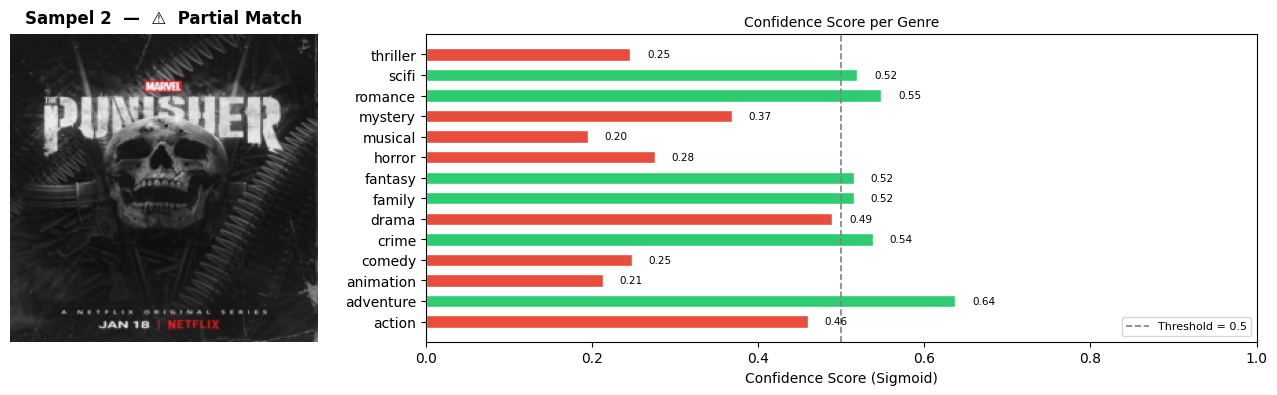


Sampel 2:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'crime', 'drama', 'thriller']
  Prediksi     : ['adventure', 'crime', 'family', 'fantasy', 'romance', 'scifi']
  Benar  (TP)  : ['crime']
  Terlewat(FN) : ['action', 'drama', 'thriller']
  Salah  (FP)  : ['adventure', 'family', 'fantasy', 'romance', 'scifi']
────────────────────────────────────────────────────────────


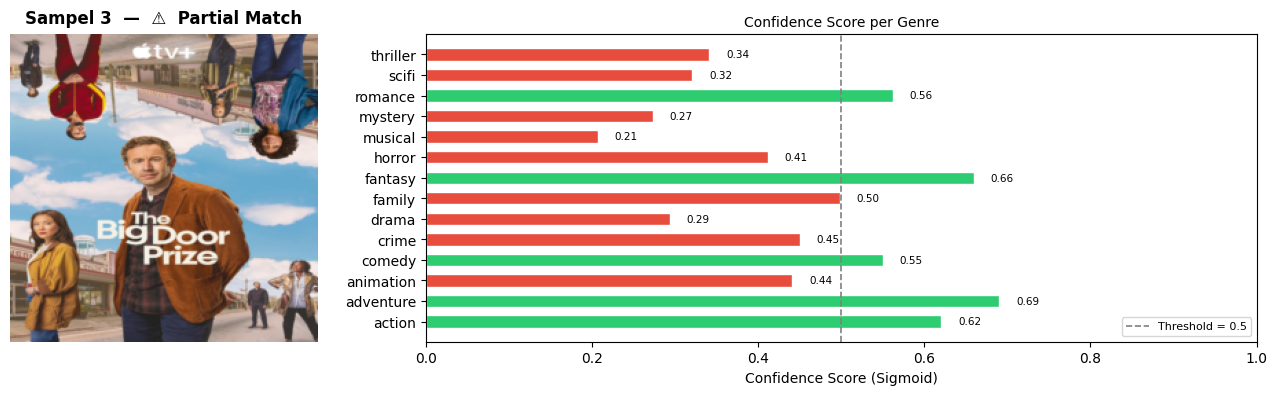


Sampel 3:
  Status       : ⚠️  Partial Match
  Label asli   : ['comedy', 'drama', 'mystery', 'scifi']
  Prediksi     : ['action', 'adventure', 'comedy', 'fantasy', 'romance']
  Benar  (TP)  : ['comedy']
  Terlewat(FN) : ['drama', 'mystery', 'scifi']
  Salah  (FP)  : ['action', 'adventure', 'fantasy', 'romance']
────────────────────────────────────────────────────────────


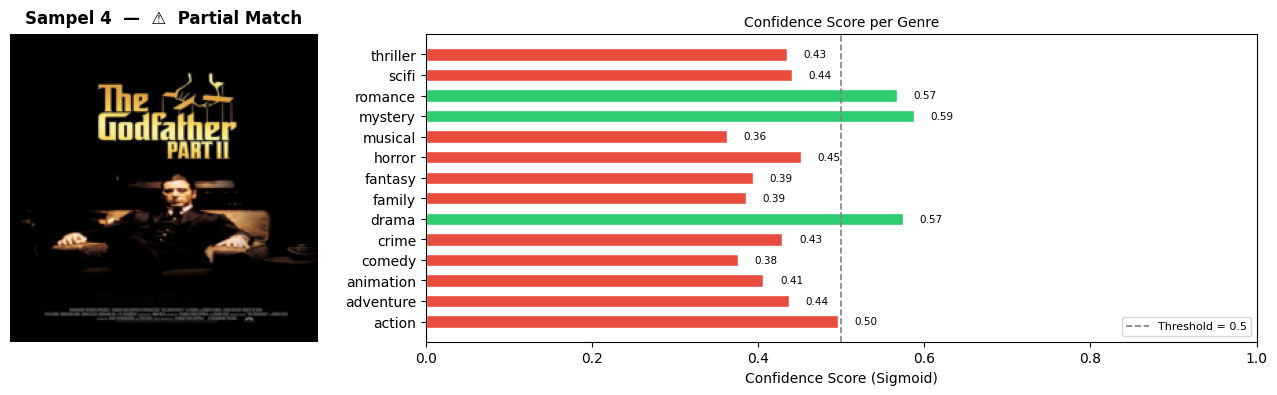


Sampel 4:
  Status       : ⚠️  Partial Match
  Label asli   : ['crime', 'drama']
  Prediksi     : ['drama', 'mystery', 'romance']
  Benar  (TP)  : ['drama']
  Terlewat(FN) : ['crime']
  Salah  (FP)  : ['mystery', 'romance']
────────────────────────────────────────────────────────────


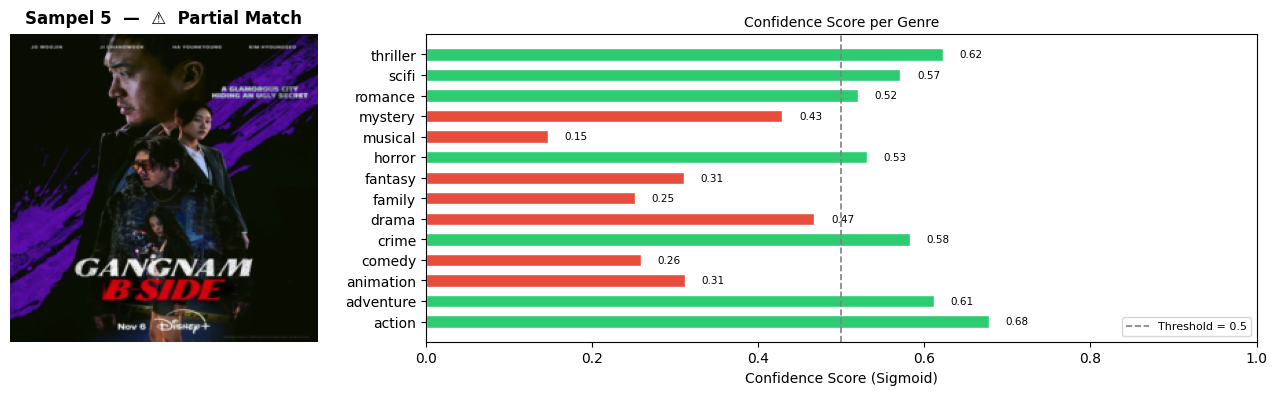


Sampel 5:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'crime', 'drama', 'mystery', 'thriller']
  Prediksi     : ['action', 'adventure', 'crime', 'horror', 'romance', 'scifi', 'thriller']
  Benar  (TP)  : ['action', 'crime', 'thriller']
  Terlewat(FN) : ['drama', 'mystery']
  Salah  (FP)  : ['adventure', 'horror', 'romance', 'scifi']
────────────────────────────────────────────────────────────


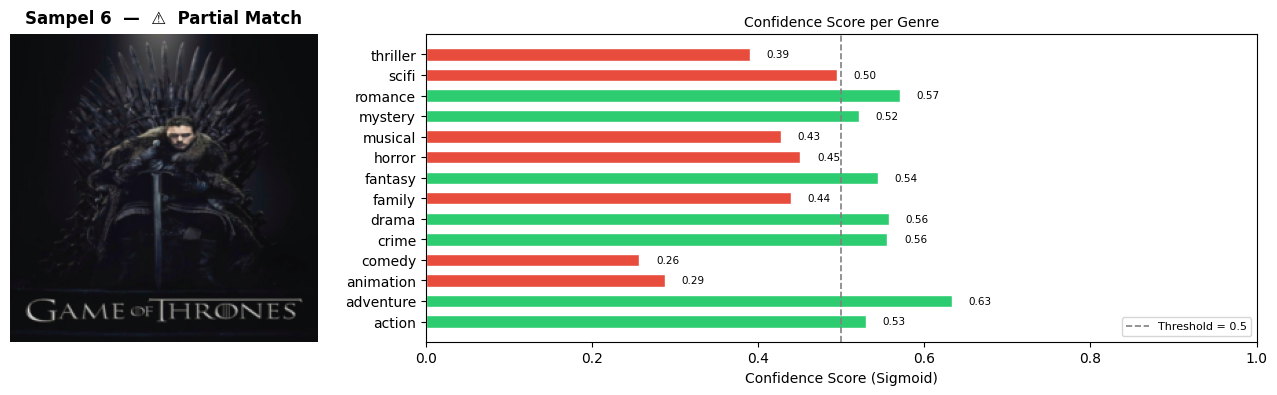


Sampel 6:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'fantasy']
  Prediksi     : ['action', 'adventure', 'crime', 'drama', 'fantasy', 'mystery', 'romance']
  Benar  (TP)  : ['action', 'adventure', 'fantasy']
  Salah  (FP)  : ['crime', 'drama', 'mystery', 'romance']
────────────────────────────────────────────────────────────


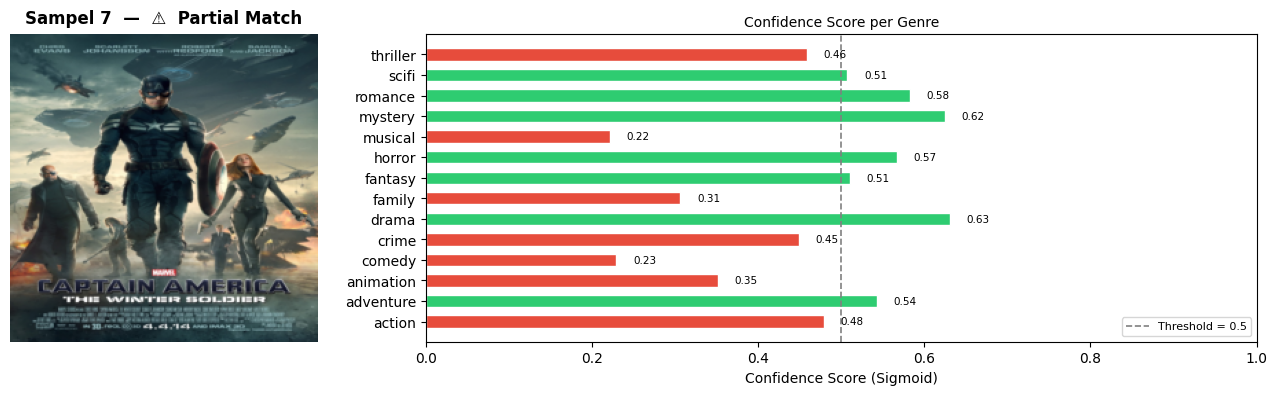


Sampel 7:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'scifi', 'thriller']
  Prediksi     : ['adventure', 'drama', 'fantasy', 'horror', 'mystery', 'romance', 'scifi']
  Benar  (TP)  : ['adventure', 'scifi']
  Terlewat(FN) : ['action', 'thriller']
  Salah  (FP)  : ['drama', 'fantasy', 'horror', 'mystery', 'romance']
────────────────────────────────────────────────────────────


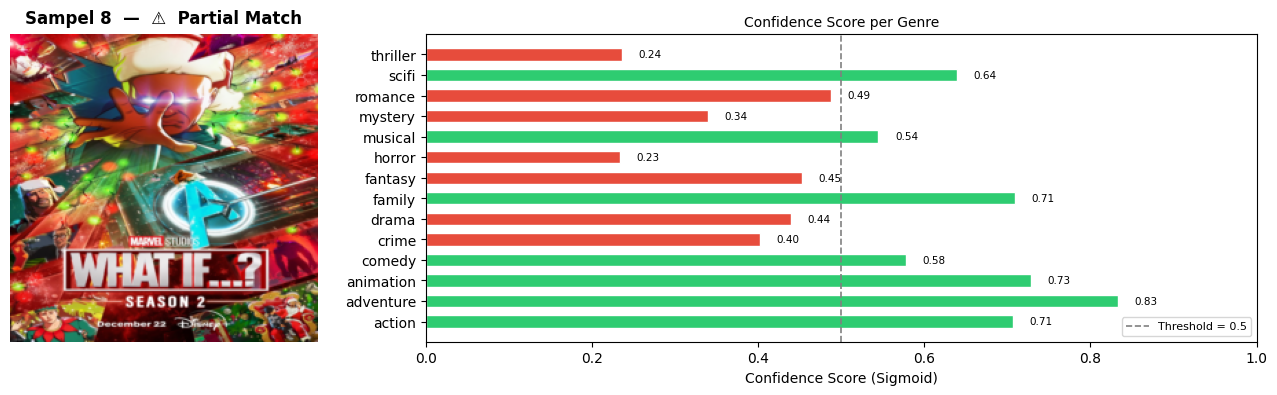


Sampel 8:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'animation', 'scifi']
  Prediksi     : ['action', 'adventure', 'animation', 'comedy', 'family', 'musical', 'scifi']
  Benar  (TP)  : ['action', 'adventure', 'animation', 'scifi']
  Salah  (FP)  : ['comedy', 'family', 'musical']
────────────────────────────────────────────────────────────


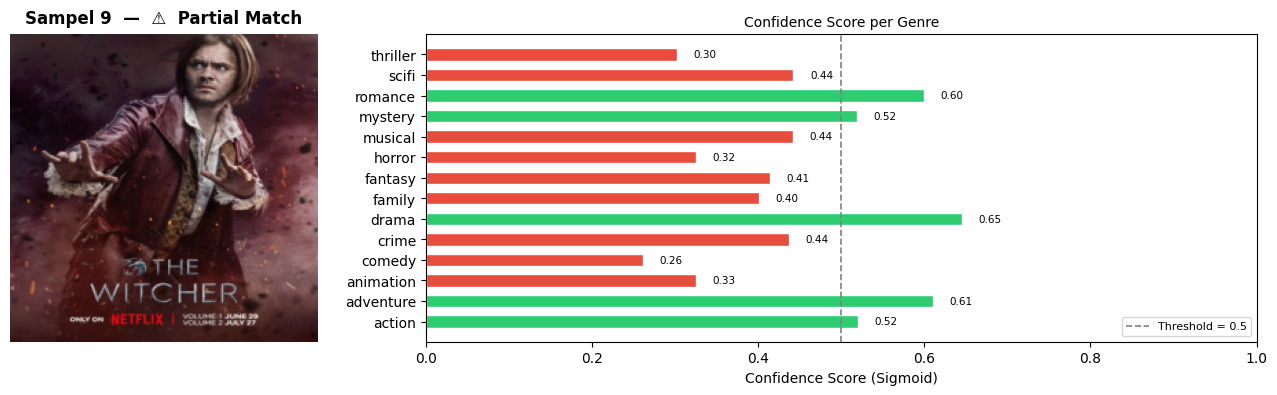


Sampel 9:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'drama']
  Prediksi     : ['action', 'adventure', 'drama', 'mystery', 'romance']
  Benar  (TP)  : ['action', 'adventure', 'drama']
  Salah  (FP)  : ['mystery', 'romance']
────────────────────────────────────────────────────────────


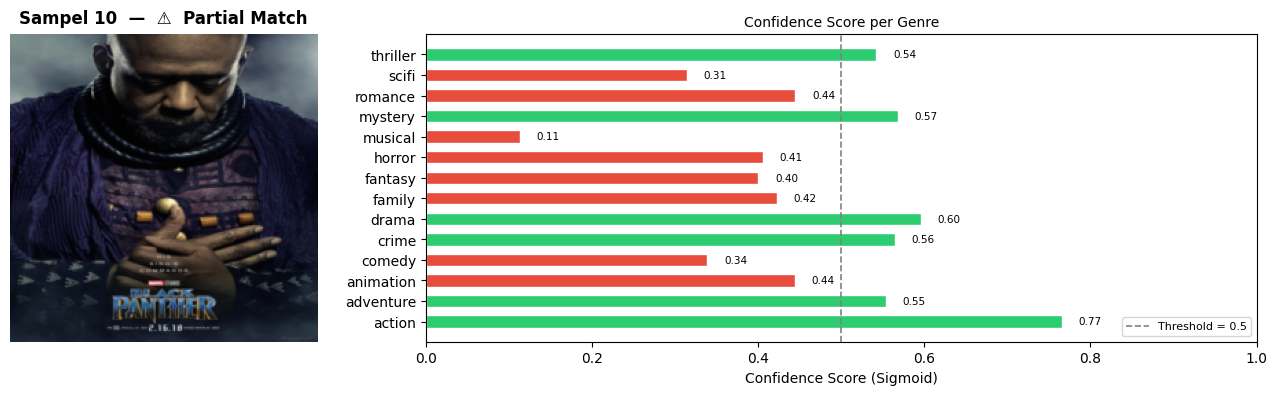


Sampel 10:
  Status       : ⚠️  Partial Match
  Label asli   : ['action', 'adventure', 'scifi']
  Prediksi     : ['action', 'adventure', 'crime', 'drama', 'mystery', 'thriller']
  Benar  (TP)  : ['action', 'adventure']
  Terlewat(FN) : ['scifi']
  Salah  (FP)  : ['crime', 'drama', 'mystery', 'thriller']
────────────────────────────────────────────────────────────

Semua hasil tersimpan : /kaggle/working/DenseNet121_results.pt

════════════════════════════════════════════════════════════
  RINGKASAN AKHIR — DenseNet121
════════════════════════════════════════════════════════════
  Loss Function   : FocalLoss(gamma=2.0) + pos_weight boost
  Best metric     : Val F1-macro (bukan F1-micro)
  Threshold       : 0.5 (seragam semua model)
  Total epoch     : 50 (10+40)
  Best epoch      : 35
  Parameter       : 6,968,206
  Test F1-micro   : 0.4872
  Test F1-macro   : 0.4143
  Test mAP        : 0.4741
  Hamming Loss    : 0.3429
  Exact Match     : 0.0000
  AUC-ROC         : 0.6528
  Train Time

In [ ]:
# ════════════════════════════════════════════════════════════
# CELL 12 — Inferensi dengan fixed seed (agar data test seragam)
# ════════════════════════════════════════════════════════════

import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import torch

# Konstanta inferensi 
INFER_SEED = 42
N_SAMPLES  = 10
INDICES_PATH = '/kaggle/working/sample_indices.npy'

print(f"INFERENSI — Contoh Prediksi pada Test Set")
print(f"Threshold  : {THRESHOLD} (seragam, sama dengan model lain)")
print(f"Seed       : {INFER_SEED} (seragam, sama dengan model lain)")
print(f"N sampel   : {N_SAMPLES}")
print("=" * 60)

# Pilih / load indeks sampel
if os.path.exists(INDICES_PATH):
    sample_indices = np.load(INDICES_PATH)
    print(f"✓ Loaded sample_indices dari: {INDICES_PATH}")
else:
    rng = np.random.default_rng(INFER_SEED)
    sample_indices = rng.choice(len(X_test), size=N_SAMPLES, replace=False)
    sample_indices = np.sort(sample_indices)
    np.save(INDICES_PATH, sample_indices)
    print(f"✓ sample_indices dibuat dan disimpan ke: {INDICES_PATH}")

print(f"  Indeks   : {sample_indices.tolist()}")
print()

# Inferensi
model.eval()

sample_imgs   = X_test[sample_indices].to(device)
sample_labels = y_test[sample_indices].numpy().astype(int)

with torch.no_grad():
    sample_outputs = model(sample_imgs)
    sample_probs   = torch.sigmoid(sample_outputs).cpu().numpy()

sample_preds = (sample_probs > THRESHOLD).astype(int)

# Denormalisasi gambar untuk ditampilkan
IMAGENET_MEAN = np.array([0.485, 0.456, 0.406])
IMAGENET_STD  = np.array([0.229, 0.224, 0.225])

def denormalize(tensor_img):
    """Kembalikan tensor [C,H,W] ke numpy [H,W,C] untuk imshow."""
    img = tensor_img.cpu().numpy().transpose(1, 2, 0)
    img = img * IMAGENET_STD + IMAGENET_MEAN
    return np.clip(img, 0, 1)

# Tampilkan hasil per sampel
print(f"{'─'*60}")

for idx in range(N_SAMPLES):
    true_genres = [GENRE_COLS[i] for i in range(N_GENRES) if sample_labels[idx][i] == 1]
    pred_genres = [GENRE_COLS[i] for i in range(N_GENRES) if sample_preds[idx][i]  == 1]
    correct = set(true_genres) & set(pred_genres)
    missed  = set(true_genres) - set(pred_genres)
    false_p = set(pred_genres) - set(true_genres)

    # Tentukan status match
    if set(true_genres) == set(pred_genres):
        status = "✅ Exact Match"
    elif correct:
        status = "⚠️  Partial Match"
    else:
        status = "❌ Wrong"

    # Gambar poster
    fig = plt.figure(figsize=(13, 4))
    gs  = gridspec.GridSpec(1, 2, width_ratios=[1, 2.5], figure=fig)

    # Panel kiri: poster
    ax_img = fig.add_subplot(gs[0])
    poster_np = denormalize(X_test[sample_indices[idx]])
    ax_img.imshow(poster_np)
    ax_img.axis('off')
    ax_img.set_title(
        f"Sampel {idx + 1}  —  {status}",
        fontsize=12, fontweight='bold', pad=8
    )

    # Panel kanan: probability bar chart
    ax_bar = fig.add_subplot(gs[1])
    probs  = sample_probs[idx]
    colors = ['#2ecc71' if probs[i] > THRESHOLD else '#e74c3c'
              for i in range(N_GENRES)]
    bars = ax_bar.barh(GENRE_COLS, probs, color=colors, edgecolor='white', height=0.6)
    ax_bar.axvline(x=THRESHOLD, color='gray', linestyle='--',
                   linewidth=1.2, label=f'Threshold = {THRESHOLD}')
    ax_bar.set_xlim(0, 1)
    ax_bar.set_xlabel('Confidence Score (Sigmoid)')
    ax_bar.set_title('Confidence Score per Genre', fontsize=10)
    ax_bar.legend(fontsize=8, loc='lower right')

    # Nilai di ujung bar
    for bar, prob in zip(bars, probs):
        ax_bar.text(
            min(prob + 0.02, 0.97), bar.get_y() + bar.get_height() / 2,
            f'{prob:.2f}', va='center', ha='left', fontsize=7.5
        )

    plt.tight_layout()
    plt.show()

    # Teks detail
    print(f"\nSampel {idx + 1}:")
    print(f"  Status       : {status}")
    print(f"  Label asli   : {true_genres}")
    print(f"  Prediksi     : {pred_genres}")
    print(f"  Benar  (TP)  : {sorted(correct)}")
    if missed:
        print(f"  Terlewat(FN) : {sorted(missed)}")
    if false_p:
        print(f"  Salah  (FP)  : {sorted(false_p)}")
    print(f"{'─'*60}")

# Simpan semua hasil
results_path = f'/kaggle/working/{MODEL_NAME}_results.pt'
torch.save({
    "model_name"              : MODEL_NAME,
    "best_weights"            : best_weights,
    "best_epoch"              : best_epoch,
    "total_params"            : total_params,
    "avg_epoch_time_s"        : avg_epoch_time,
    "avg_infer_ms"            : avg_infer_ms,
    "threshold"               : THRESHOLD,
    "loss_function"           : "FocalLoss(gamma=2.0)",
    "val_loss"                : val_m_final['loss'],
    "test_loss"               : test_m['loss'],
    "test_f1_micro"           : test_m['f1_micro'],
    "test_f1_macro"           : test_m['f1_macro'],
    "test_f1_weighted"        : test_m['f1_weighted'],
    "test_f1_per_genre"       : test_m['f1_per_genre'],
    "test_precision_micro"    : test_m['precision_micro'],
    "test_precision_macro"    : test_m['precision_macro'],
    "test_precision_weighted" : test_m['precision_weighted'],
    "test_recall_micro"       : test_m['recall_micro'],
    "test_recall_macro"       : test_m['recall_macro'],
    "test_recall_weighted"    : test_m['recall_weighted'],
    "test_mAP"                : test_m['mAP'],
    "test_auc_roc"            : test_m['auc_roc'],
    "test_hamming_loss"       : test_m['hamming_loss'],
    "test_exact_match"        : test_m['exact_match'],
    "history"                 : history,
    "genre_cols"              : GENRE_COLS,
    "phase1_epochs"           : PHASE1_EPOCHS,
    "phase2_epochs"           : PHASE2_EPOCHS,
    "total_epochs"            : TOTAL_EPOCHS,
    "sample_indices"          : sample_indices.tolist(),
}, results_path)

print(f"\nSemua hasil tersimpan : {results_path}")
print(f"\n{'═'*60}")
print(f"  RINGKASAN AKHIR — {MODEL_NAME}")
print(f"{'═'*60}")
print(f"  Loss Function   : FocalLoss(gamma=2.0) + pos_weight boost")
print(f"  Best metric     : Val F1-macro (bukan F1-micro)")
print(f"  Threshold       : {THRESHOLD} (seragam semua model)")
print(f"  Total epoch     : {TOTAL_EPOCHS} ({PHASE1_EPOCHS}+{PHASE2_EPOCHS})")
print(f"  Best epoch      : {best_epoch}")
print(f"  Parameter       : {total_params:,}")
print(f"  Test F1-micro   : {test_m['f1_micro']:.4f}")
print(f"  Test F1-macro   : {test_m['f1_macro']:.4f}")
print(f"  Test mAP        : {test_m['mAP']:.4f}")
print(f"  Hamming Loss    : {test_m['hamming_loss']:.4f}")
print(f"  Exact Match     : {test_m['exact_match']:.4f}")
print(f"  AUC-ROC         : {test_m['auc_roc']:.4f}")
print(f"  Train Time/Epoch: {avg_epoch_time:.1f}s")
print(f"  Infer Time/Img  : {avg_infer_ms:.2f}ms")
print(f"{'═'*60}")
print(f"\nSelesai. Klik Save Version untuk menyimpan notebook.")
